In [22]:
import xarray as xr
import isku_utils
import cdsapi

import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt

from dotenv import load_dotenv
import os

# API Data Download

In [51]:
### Projection ###

dataset = "projections-climate-atlas"
request = {
    "origin": "cmip6",
    "experiment": "ssp2_4_5",
    "domain": "global",
    "period": "2015-2100",
    "variable": "monthly_mean_of_daily_mean_temperature"
}

client = cdsapi.Client()
client.retrieve(dataset, request, "./data/cmip6_2015_2100_monthly_tmean_ssp245.nc")


2026-07-28 14:27:04,351 INFO Request ID is 8c19c3fa-d331-4d0e-a4a0-c5aeca20d188
2026-07-28 14:27:04,524 INFO status has been updated to accepted
2026-07-28 14:27:28,112 INFO status has been updated to running
2026-07-28 14:38:11,506 INFO status has been updated to successful


e13e563ea85ba90a254ad7913dd442ea.zip:   0%|          | 0.00/3.21G [00:00<?, ?B/s]

Recovering from connection error [('Connection broken: IncompleteRead(4014080 bytes read, 3441475047 more expected)', IncompleteRead(4014080 bytes read, 3441475047 more expected))], attempt 1 of 500
Retrying in 120 seconds


e13e563ea85ba90a254ad7913dd442ea.zip:   0%|          | 3.00M/3.21G [00:00<?, ?B/s]

KeyboardInterrupt: 

In [ ]:
### Historical ###
dataset = "projections-climate-atlas"
request = {
    "origin": "cmip6",
    "experiment": "historical",
    "domain": "global",
    "period": "1850-2014",
    "variable": "monthly_mean_of_daily_mean_temperature"
}

client = cdsapi.Client()
client.retrieve(dataset, request, "./data/cmip6_hist_1850_2014_monthly_tmean.nc")


In [ ]:
## Monthly Hindcast
import cdsapi

dataset = "seasonal-monthly-single-levels"
request = {
    "originating_centre": "ecmwf",
    "system": "51",
    "variable": ["2m_temperature"],
    "product_type": [
        "monthly_mean"
    ],
    "year": [
        "1981", "1982", "1983",
        "1984", "1985", "1986",
        "1987", "1988", "1989",
        "1990", "1991", "1992",
        "1993", "1994", "1995",
        "1996", "1997", "1998",
        "1999", "2000", "2001",
        "2002", "2003", "2004",
        "2005", "2006", "2007",
        "2008", "2009", "2010",
        "2011", "2012", "2013",
        "2014"
    ],
    "month": ["07"],
    "leadtime_month": [
        "1",
        "2",
        "3",
        "4",
        "5",
        "6"
    ],
    "data_format": "netcdf"
}

client = cdsapi.Client()
client.retrieve(dataset, request, "./data/seas5_1981_2014_monthly_tmean_2.nc")


In [ ]:
## Monthly Forecast
dataset = "seasonal-monthly-single-levels"
request = {
    "originating_centre": "ecmwf",
    "system": "51",
    "variable": ["2m_temperature"],
    "product_type": [
        "monthly_mean"
    ],
    "year": [
        "2026"
    ],
    "month": ["07"],
    "leadtime_month": [
        "1",
        "2",
        "3",
        "4",
        "5",
        "6"
    ],
    "data_format": "netcdf"
}

client = cdsapi.Client()
client.retrieve(dataset, request, "./data/seas5_202607_monthly_tmean.nc")

# Data Processing

In [ ]:
import zipfile
with zipfile.ZipFile("./data/seas5_1981_2014_monthly_tmean_2.nc") as z:
    z.extractall("./data/")

In [ ]:
with zipfile.ZipFile("./data/seas5_1981_2014_monthly_tmean.nc") as z:
    print(z.namelist())

# Load Data

In [2]:
#Define Forecast Months
fc_months = [7, 8, 9, 10, 11, 12]

In [3]:
## CMIP6 Projections
ar6_project = xr.open_dataset("/home/emily_zuetell/projects/poreallas/scripts/data/t_CMIP6_ssp245_mon_201501-210012.nc")
ar6_hist = xr.open_dataset("/home/emily_zuetell/projects/poreallas/scripts/data/t_CMIP6_historical_mon_185001-201412.nc")

/home/emily_zuetell/projects/poreallas/.venv/lib/python3.14/site-packages/xarray/conventions.py:205: SerializationWarning: variable 't' has multiple fill values {np.float32(1.0384594e+34), np.float32(-1.7014118e+38)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/home/emily_zuetell/projects/poreallas/.venv/lib/python3.14/site-packages/xarray/conventions.py:205: SerializationWarning: variable 't' has multiple fill values {np.float32(1.0384594e+34), np.float32(-1.7014118e+38)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)


In [4]:
#IPCC Recent Baseline Period 1995-2014
hist_mean = ar6_hist['t'].sel(time = slice("1995-01-01", "2014-12-01")).groupby("time.month").mean()
hist_mean = hist_mean.sel(month = fc_months).mean(dim = 'month')

In [5]:
projection = ar6_project['t']
projection = projection.assign_coords(year=projection.time.dt.year, month=projection.time.dt.month)
projection = projection.set_index(time=["year", "month"]).unstack("time")
projection = projection.sel(month = fc_months).mean(dim = 'month')

In [6]:
### Seasonal Forecast ###

#Load Hindcast
hindcast = xr.open_dataset("/home/emily_zuetell/projects/poreallas/scripts/data/seas5_1981_2014_monthly_tmean_2.nc")
#Align lat/lon
hindcast = hindcast.rename({'latitude': 'lat', 'longitude': 'lon'})
hindcast = hindcast.assign_coords(lon=(((hindcast.lon + 180) % 360) - 180)).sortby("lon")

#Select hindcast period
hindcast = hindcast.sel(forecast_reference_time = slice("1995-01-01", "2014-12-01"))
#Define month dimension
hindcast["month"] = (
    hindcast["forecast_reference_time"].dt.month + hindcast["forecastMonth"]
).squeeze() - 1
hindcast = hindcast.assign_coords(month=("forecastMonth", hindcast["month"].isel(forecast_reference_time=0).values))
hindcast = hindcast.swap_dims({"forecastMonth": "month"})
#Annual mean over forecast months
hindcast = hindcast.sel(month = fc_months).groupby('forecast_reference_time.year').mean()
#Hindcast period mean
hindcast = hindcast.mean(dim = ['year', 'month'])

In [7]:
forecast = xr.open_dataset('/home/emily_zuetell/projects/poreallas/scripts/data/seas5_202607_monthly_tmean.nc')
#Align lat/lon
forecast = forecast.rename({'latitude': 'lat', 'longitude': 'lon'})
forecast = forecast.assign_coords(lon=(((forecast.lon + 180) % 360) - 180)).sortby("lon")
#Define month dimension
forecast["month"] = (
    forecast["forecast_reference_time"].dt.month + forecast["forecastMonth"]
).squeeze() - 1
forecast = forecast.swap_dims({"forecastMonth": "month"}).squeeze()
#6-mo avg
forecast = forecast.mean(dim = 'month')

# Distributions + Testing

In [8]:
## Statistics ##
# Climate Projection
mean_proj = projection.mean(dim = 'member')
var_proj = (projection.std(dim = 'member'))**2
n_proj = len(projection.member)

mean_base = hist_mean.mean(dim = 'member')
var_base = (hist_mean.std(dim = 'member'))**2
n_base = len(hist_mean.member)

anomaly_proj = mean_proj-mean_base
#Rolling avg
anomaly_proj = anomaly_proj.rolling(year=5, center=False, min_periods=5).mean()
var_anomaly_proj = (var_proj/n_proj)+(var_base/n_base)

# Seasonal Forecast
mean_fc = forecast['t2m'].mean(dim = 'number')
var_fc = (forecast['t2m'].var(dim = 'number'))
n_fc = len(forecast['t2m'].number)

mean_hc = hindcast['t2m'].mean(dim = 'number')
var_hc = (hindcast['t2m'].var(dim = 'number'))
n_hc = len(hindcast['t2m'].number)

anomaly_fc = mean_fc-mean_hc
var_anomaly_fc = (var_fc/n_fc)+(var_hc/n_hc)

In [12]:
## Probability of Surpassing Projection Anomaly
diff = anomaly_fc-anomaly_proj
var_diff = var_anomaly_fc + var_anomaly_proj
#var_diff = var_anomaly_fc #Forecast uncertainty only (No projection uncertainty)
z = diff/np.sqrt(var_diff)
p_surpass = xr.apply_ufunc(norm.cdf, z)

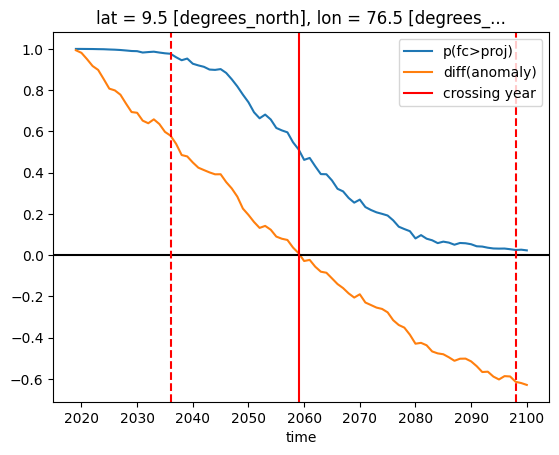

In [15]:
#lat, lon = 42, 49
lat, lon = 9.9312, 76.2673
fig, ax = plt.subplots()
p_surpass.sel(lat=lat, lon = lon, method = 'nearest').plot(ax = ax, label = "p(fc>proj)")
diff.sel(lat=lat, lon = lon, method = 'nearest').plot(ax = ax, label = "diff(anomaly)")
ax.axhline(0, color = 'k')
ax.axvline(p_surpass.sel(lat=lat, lon = lon, method = 'nearest').where(p_surpass.sel(lat=lat, lon = lon, method = 'nearest') >= 0.5).idxmin('year'), color = 'red', label = 'crossing year')
ax.axvline(p_surpass.sel(lat=lat, lon = lon, method = 'nearest').where(p_surpass.sel(lat=lat, lon = lon, method = 'nearest') >= 0.025).idxmin('year'), color = 'red', linestyle = '--')
ax.axvline(p_surpass.sel(lat=lat, lon = lon, method = 'nearest').where(p_surpass.sel(lat=lat, lon = lon, method = 'nearest') >= 0.975).idxmin('year'), color = 'red', linestyle = '--')
ax.legend()

In [10]:
#Empirical Version
emp_diff = (forecast['t2m']-hindcast['t2m']-anomaly_proj)
years_emp = emp_diff.where(emp_diff <= 0).idxmax('year')

#Save Out
quantiles = years_emp.quantile([0.1, 0.5, 0.9], dim='number')
crossing_year = quantiles.sel(quantile = 0.5).drop_vars('quantile')
ci_low = quantiles.sel(quantile = 0.1).drop_vars('quantile')
ci_high = quantiles.sel(quantile = 0.9).drop_vars('quantile')
ci_low = ci_low.fillna(2014)
ci_high = ci_high.fillna(2101)

ci_width = ci_high - ci_low

ds_out = xr.Dataset({
    'crossing_year': crossing_year,
    'ci_width_95': ci_width,
    'ci_10': ci_low,
    'ci_90':ci_high
})

#ds_out.to_zarr('./data/2607_fc_anomaly_year_fcvarOnly_emp_ssp245.zarr')

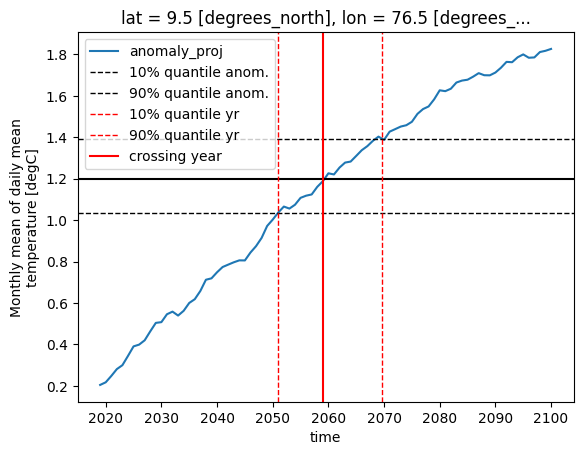

In [17]:
#lat, lon = 42, 49
lat, lon = 9.9312, 76.2673
fig, ax = plt.subplots()
data = (forecast['t2m']-hindcast['t2m']).sel(lat=lat, lon = lon, method = 'nearest')
anomaly_proj.sel(lat=lat, lon = lon, method = 'nearest').plot(ax = ax, label = "anomaly_proj")

ax.axhline(anomaly_fc.sel(lat=lat, lon = lon, method = 'nearest'), color = 'k')

quantiles = data.quantile([0.1, 0.9], dim='number')
for q, val in zip(quantiles['quantile'].values, quantiles.values):
    ax.axhline(val, color='k', linestyle='--', linewidth=1, label=f'{q:.0%} quantile anom.')

quantiles = years_emp.sel(lat=lat, lon = lon, method = 'nearest').quantile([0.1, 0.9], dim='number')
for q, val in zip(quantiles['quantile'].values, quantiles.values):
    ax.axvline(val, color='red', linestyle='--', linewidth=1, label=f'{q:.0%} quantile yr')
    

ax.axvline(p_surpass.sel(lat=lat, lon = lon, method = 'nearest').where(p_surpass.sel(lat=lat, lon = lon, method = 'nearest') >= 0.5).idxmin('year'), color = 'red', label = 'crossing year')
ax.legend()

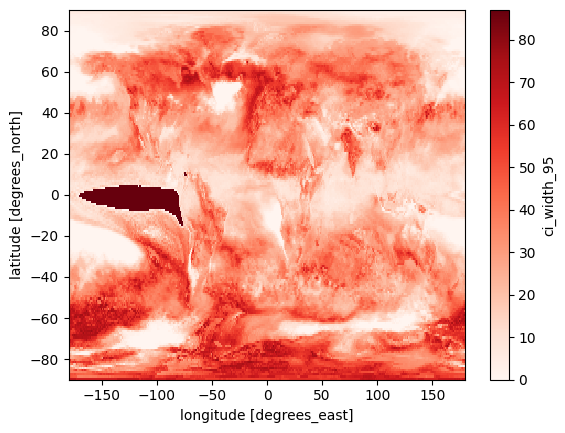

In [18]:
ds_out['ci_width_95'].plot(cmap = 'Reds', vmin = 0)

# Final Data

In [ ]:
data_ir = isku_utils.grid_to_ir(ds_out)

In [23]:
import analysis_utils
import geopandas as gpd

load_dotenv()
DATA_DIR = os.environ["DATA_DIR"]
IMPACT_REGION_POLYGONS = os.environ["POREALLAS_REGIONS_POLYGONS_URI"]

_polygons = (
    gpd.read_parquet(IMPACT_REGION_POLYGONS)
    .rename(columns={"hierid": "region"})
    .set_index("region")
    .set_crs(epsg=4326)  # Assuming the data is WGS-82.
)

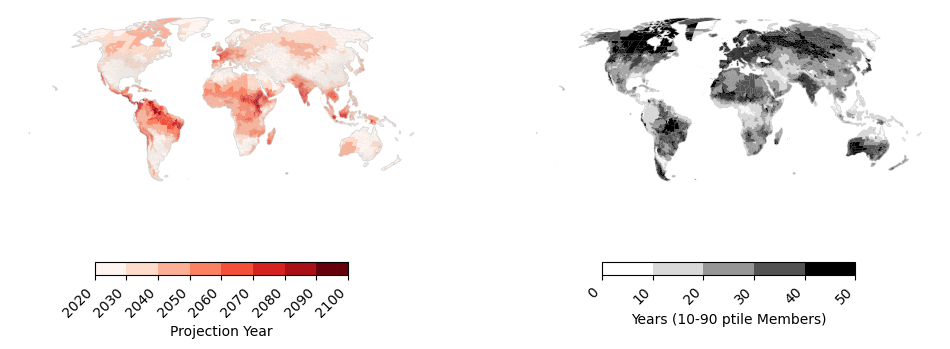

In [25]:
_polygons_postcard = analysis_utils.xarray_to_gpd(data_ir, _polygons)

fig, axs = plt.subplots(1,2, figsize = (12,6))
analysis_utils.plot_single(
    _polygons_postcard,
    col='crossing_year',
    cm = 'Reds',
    vmin = 2020,
    vmax = 2100,
    cbar_label= 'Projection Year',
    ax = axs[0],
    cbar_location='bottom'
)

_polygons_postcard = analysis_utils.xarray_to_gpd(data_ir, _polygons)
analysis_utils.plot_single(
    _polygons_postcard,
    col='ci_width_95',
    cm = 'Grays',
    vmin = 0,
    vmax = 50,
    cbar_label= 'Years (10-90 ptile Members)',
    ax = axs[1],
    cbar_location='bottom'
)

fig.savefig("2607_combined_spread_postcard", dpi=600, bbox_inches="tight")